In [3]:
# importing libraries used in this book
import numpy as np
import matplotlib.pyplot as plt


## Méthode de Newton

Soit $f:\mathbb R \rightarrow\mathbb R$ une fonction différentiable.

Soit $x^{(0)}$ un point donné. On considère l'équation de la droite $y(x)$ qui
passe par le point $(x^{(k)},f(x^{(k)}))$ et qui a comme pente
$f'(x^{(k)})$,
\begin{equation*}
  y(x)=f'(x^{(k)})(x-x^{(k)})+f(x^{(k)}).
\end{equation*}
On définit $x^{(k+1)}$ comme étant le point où cette droite
intersecte l'axe $x$, c'est-à-dire $y(x^{(k+1)})=0$.  On en
déduit que :
$$ x^{(k+1)}=x^{(k)}-\frac{f(x^{(k)})}{f'(x^{(k)})},\,\,\,k=0,1,2\ldots .$$



#### Exercice (5, Série 1)

On cherche les zéros de la fonction

$$f(x) = \dfrac{1}{2} \sin \left( \dfrac{\pi x}{2} \right) + 1 - x \; .$$


1. Vérifiez qu'il y a au moins un zéro $\alpha$ dans l'intervalle $[0,2]$.

2. Ecrivez la méthode de Newton pour trouver le zéro $\alpha$ de la fonction $f(x)$ et
calculez la première itération à partir de la valeur initiale $x^{(0)}=1$.

3. Calculez les zéros $\alpha$ de la fonction
  $f$ avec la méthode de Newton (fonction `newton` que vous devrez écrire)

```python
def  Newton( F, dF, x0, tol, nmax ) :
    # NEWTON Find the zeros of a nonlinear equations.
    # NEWTON(F,DF,X0,TOL,NMAX) tries to find the zero X of the 
    # continuous and differentiable function F nearest to X0 using 
    # the Newton method. DF is a function which take X and return the derivative of F.
    # If the search fails an error message is displayed.
    # 
    # returns the value of the
    # residual R in X,the number of iterations N required for computing X and
    # INC the increments computed by Newton.
    
    return x, r, n, inc
```

Choisissez $x^{(0)} = 1$ comme point de départ pour la méthode
et utilisez une tolérance $tol=10^{-4}$ sur la valeur absolue de l'incrément
entre deux itérations
successives $|x^{(k+1)}-x^{(k)}|$. 

*Dans le cas de la méthode de Newton,
l'incrément est une bonne approximation de l'erreur.*



In [4]:
def  Newton( F, dF, x0, tol, nmax ) :
    '''
    NEWTON Find the zeros of a nonlinear equations.
    NEWTON(F,DF,X0,TOL,NMAX) tries to find the zero X of the 
    continuous and differentiable function F nearest to X0 using 
    the Newton method. DF is a function which take X and return the derivative of F.
    If the search fails an error message is displayed.
     
    Outputs : [x, r, n, inc, x_sequence]
    x : the approximated root of the function
    r : the absolute value of the residualin X
    n : the number of iterations N required for computing X and
    inc : the increments computed by Newton.
    x_sequence : the sequence computed by Newton
    '''
    
    # Initial values
    n = 0
    xk = x0
    eps = tol
    # initialisation of loop components
    # increments (in abs value) at each iteration
    inc = []
    # in case we wish to plot the sequence 
    x = [x0]
    
    # (Complete the code below)
    for k in range(nmax):
        xk = x[k]
        rk = abs(F(xk))

        if k != 0 :
            inc.append(abs(xk-x[k-1]))
        if k < eps :
            return x0, rk, k, inc, np.array(x)
        
        dFxk = dF(xk)

        if dFxk != 0 :
            x.append(xk - F(xk)/dF(xk))
        else :
            print("cannot find the zero because dFxk = 0")
            
            
    # Warning if not converged
    if n > nmax :
        print('Newton stopped without converging to the desired tolerance ')
        print('because the maximum number of iterations was reached')
        
        # (Complete the code below)
        
        
    return xk, rk, n, inc, np.array(x)

In [6]:
f  = lambda x : 0.5*np.sin(np.pi*x/2)+1-x
df = lambda x : 0.25*np.pi*np.cos(np.pi*x/2)-1

x0   = 1
tol  = 1e-4
nmax = 10

zero, residual, niter, inc, x = Newton(f, df, x0, tol, nmax)

print(f'The zero computed is {zero:1.4f}')
print(f'Newton stoppedconverged in {niter} iterations'); 
print(f'with a residual of {residual:1.4e}.\n')


The zero computed is 1.0000
Newton stoppedconverged in 0 iterations
with a residual of 5.0000e-01.



In [7]:
from NonLinearEquationsLib import plotNewtonIterations

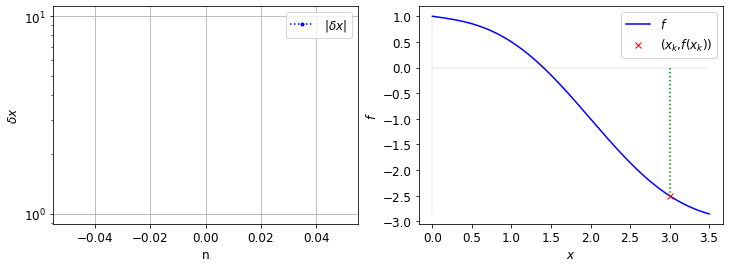

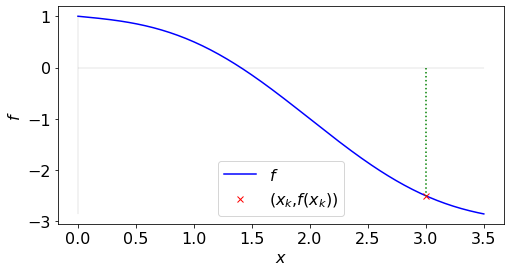

In [8]:
[a,b] = [0,3.5]
x0   = 3
zero, residual, niter, inc, x = Newton(f, df, x0, tol, nmax)

# Rezise plots, which are usually too small
plt.figure(figsize=(12, 4))
plt.rcParams.update({'font.size': 12})

# Subplot 1 over 2, 1st one
plt.subplot(121)

#plt.plot(range(MaxIterations), RelativeError, 'b:.')
plt.plot(range(niter), inc, 'b:.')
         
plt.xlabel('n'); plt.ylabel('$\\delta x$');
plt.grid(True)
#plt.xscale('log') 
plt.yscale('log')
plt.legend(['$|\\delta x|$'])


# Subplot 1 over 2, 2nd one
plt.subplot(122)

plotNewtonIterations (a,b,f,x,200)

plt.show()

# Rezise plots, which are usually too small
plt.figure(figsize=(8, 4))
plt.rcParams.update({'font.size': 16})

plotNewtonIterations (a,b,f,x,200)
# plt.savefig('Newton-iterations.png', dpi=600)
plt.show()

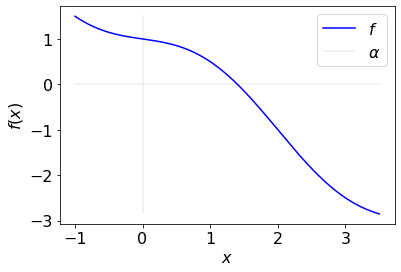

In [9]:
[a,b] = [-1,3.5]
z = np.linspace(a,b,200)
plt.plot(z,f(z), 'b-')
plt.ylabel('$f(x)$'); plt.xlabel('$x$')

# Plot the x,y-axis 
plt.plot([a,b], [0,0], 'k-',linewidth=0.1)
plt.plot([0,0], [np.min(f(z)),np.max(f(z))], 'k-',linewidth=0.1)

plt.legend(['$f$','$\\alpha$'])
# plt.savefig('Newton-fx-alpha.png', dpi=600)

plt.show()

